<>:61: SyntaxWarning: invalid escape sequence '\A'
<>:61: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_187468/391121172.py:61: SyntaxWarning: invalid escape sequence '\A'
  textstr = f"MAE = {mae:.2f} \AA$^3$\n$R^2$ = {r2:.2f}"


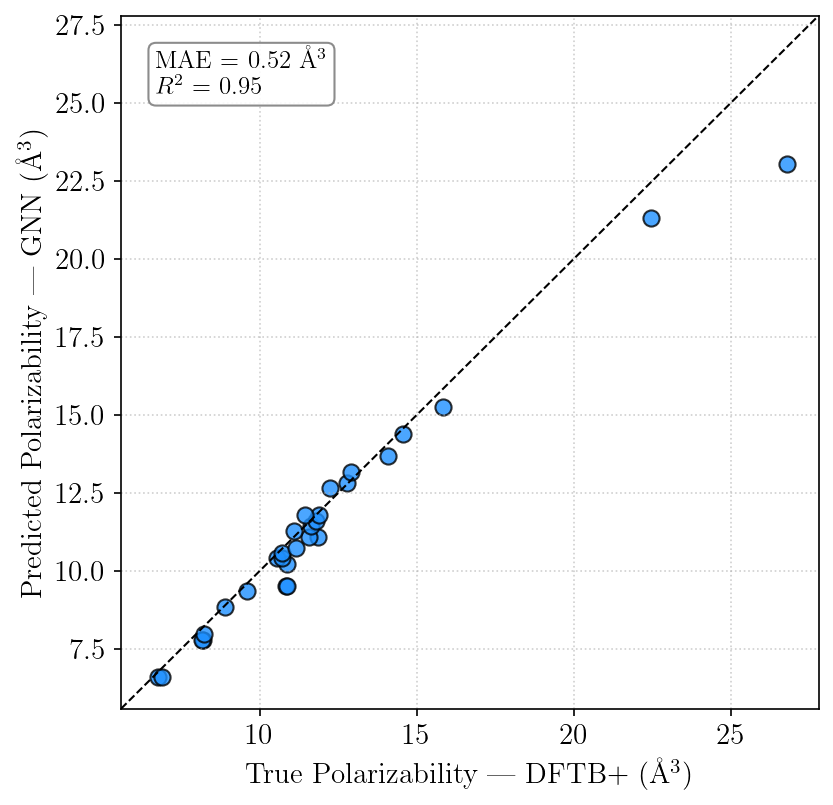

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import mean_absolute_error, r2_score

# Apply LaTeX formatting for the plot
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
})

# 1. Load datasets
df_ga = pd.read_csv('df_ga_output.csv')
df_dftb = pd.read_csv('polarizability_data.csv')

# 2. Merge on SMILES with EXPLICIT suffixes
df_merged = pd.merge(
    df_ga, 
    df_dftb, 
    left_on='smiles', 
    right_on='smiles_A', 
    suffixes=('_pred', '_dftb') # This renames the overlapping columns
)

# 3. Convert DFTB+ polarizability from Bohr^3 to Angstrom^3
BOHR_TO_ANGSTROM_CUBED = 0.14818474

# Use the explicitly suffixed DFTB column name here: 'static_polarizability_dftb'
df_merged['static_polarizability_dftb_A3'] = df_merged['static_polarizability_dftb'] * BOHR_TO_ANGSTROM_CUBED

# 4. Extract arrays for comparison
y_true = df_merged['static_polarizability_dftb_A3']
y_pred = df_merged['static_polarizability_pred_original']

# Compute metrics
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# 5. Generate Parity Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, color='dodgerblue', alpha=0.8, edgecolor='k', s=60)

# Ideal reference line
min_val = min(y_true.min(), y_pred.min()) - 1
max_val = max(y_true.max(), y_pred.max()) + 1
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)

ax.set_xlabel(r"True Polarizability --- DFTB+ (\AA$^3$)")
ax.set_ylabel(r"Predicted Polarizability --- GNN (\AA$^3$)")

# Add a text box for the metrics
textstr = f"MAE = {mae:.2f} \AA$^3$\n$R^2$ = {r2:.2f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.grid(True, linestyle=':', alpha=0.6)

# 6. Save and show
plt.savefig("dftb_vs_gnn_parity.pdf", format='pdf')
plt.show()